<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>استفاده از تبدیل در دیتاست‌ها</b>
  </p>
</div>

---

<div dir="rtl" style="text-align: right;">
تغییر پارامتر اختیاری Transform در حین ساخت دیتاست:

- تبدیل به تنسور
- نرمال‌سازی
- تغییر ابعاد تصویر
- اعمال تبدیلات به منظور آگمنت‌سازی داده:
    - بُرش‌زنی
    - چرخش
    - قرینه‌سازی
</div>

---

<div dir="rtl" style="text-align: right;">
جایگاه transform:
</div>

In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

<div dir="rtl" style="text-align: right;">
سوال: چرا ترنسفورم به جای دیتالودر در بخش دیتاست اعمال می‌شود؟
</div>

---

<div dir="rtl" style="text-align: right;">
تابع نمایش تصادفی تصاویر مجموعه داده:
</div>

In [2]:
import torch
import matplotlib.pyplot as plt

def show_random_samples(dataset, rows=3, cols=3, figsize=(4, 4), tensor=False):
    labels_map = {v: k for k, v in training_data.class_to_idx.items()}
    figure = plt.figure(figsize=figsize)
    for i in range(1, rows * cols + 1):
        sample_idx = torch.randint(len(dataset), size=(1,)).item()
        img, label = dataset[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(labels_map[label])
        plt.axis("off")
        if tensor:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img, cmap="gray")
    plt.tight_layout()
    plt.show()

---

<div dir="rtl" style="text-align: right;">
اختیاری‌بودن استفاده از پارامتر transform:
</div>

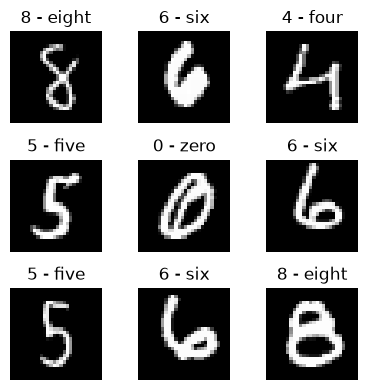

In [4]:
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    # transform=ToTensor()
)

show_random_samples(training_data)

<div dir="rtl" style="text-align: right;">
استفاده از تبدیل تغییر ابعاد:
</div>

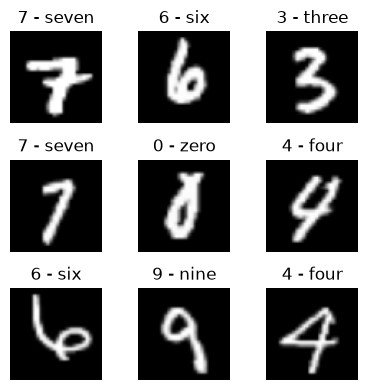

In [5]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=Resize((64, 64))
)

show_random_samples(training_data)

<div dir="rtl" style="text-align: right;">
سوال:
بررسی ابعاد تصاویر فوق و سپس اعمال تبدیل Resize روی مجموعه داده‌ی فوق برای ابعاد ۸*۸.
</div>

In [6]:
training_data[0]

(<PIL.Image.Image image mode=L size=64x64>, 5)

<div dir="rtl" style="text-align: right;">
اعمال تبدیل Flip:
</div>

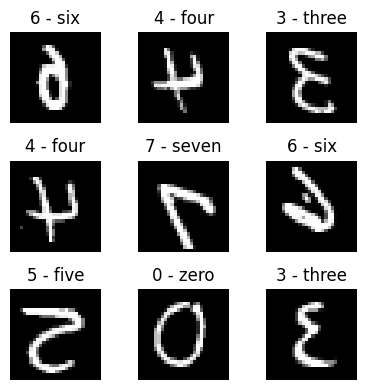

In [6]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize
from torchvision.transforms import RandomHorizontalFlip

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=RandomHorizontalFlip()
)

show_random_samples(training_data)

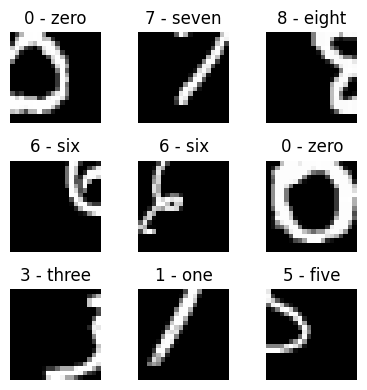

In [10]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize
from torchvision.transforms import RandomHorizontalFlip
from torchvision.transforms import RandomCrop

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=RandomCrop(20, padding=4)
    # point to CenterCrop
)

show_random_samples(training_data)

<div dir="rtl" style="text-align: right;">
سوال:
تبدیل دیگری به نام
RandomRotation
که پارامتر ورودی آن درجه چرخش تصویر است را ایمپورت نموده و بر روی مجموعه داده‌ی فوق استفاده نمایید.
سپس به کمک تابع نمایش تصادفی نمونه‌ها، چندین نمونه از مجموعه داده را نمایش دهید.
</div>

<div dir="rtl" style="text-align: right;">
سوال: آیا در استفاده آزاد از تبدیل‌ها صرف‌نظر از نوع داده مجاز هستیم؟
</div>

<div dir="rtl" style="text-align: right;">
نرمال‌سازی داده‌ها:
</div>

In [10]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize
from torchvision.transforms import RandomHorizontalFlip
from torchvision.transforms import RandomCrop
from torchvision.transforms import RandomRotation
from torchvision.transforms import Normalize

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=Normalize((0.5,), (0.5,))
)

# show_random_samples(training_data)

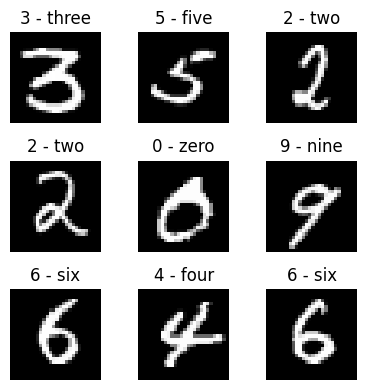

In [33]:
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize
from torchvision.transforms import RandomHorizontalFlip
from torchvision.transforms import RandomCrop
from torchvision.transforms import RandomRotation
from torchvision.transforms import Normalize

transform = transforms.Compose([
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

show_random_samples(training_data, tensor=True)

In [16]:
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize
from torchvision.transforms import RandomHorizontalFlip
from torchvision.transforms import RandomCrop
from torchvision.transforms import RandomRotation
from torchvision.transforms import Normalize

transform = transforms.Compose([
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

<div dir="rtl" style="text-align: right;">
سوال:
اثر وجود و عدم وجود نرمالیزیشن در تبدیلات را با بررسی میانگین پیکسل‌های یک تصویر مقایسه نمایید.
تصویر اول حین خواندن از دیتالودر قابل دست‌یابی است.
</div>

tensor(0.)

<div dir="rtl" style="text-align: right;">
تمرین: جمع‌بندی اعمال تبدیل در دیتاست‌ها

مجموعه داده آموزشی MNIST را درنظر گرفته و تبدیلات زیر را به صورت ترکیبی روی آن اعمال نمایید.

- Resize((32, 32))
- RandomCrop(28, padding=4)
- RandomRotation(degrees=90)
- RandomHorizontalFlip(p=0.8)
- ToTensor()
- Normalize((0.5,), (0.5,))
</div>